# Pairs Trading Strategy — Design & Backtest

This notebook presents the cointegration analysis (Steps 1–3) and Z*
optimisation (Step 4) for each pair under study, followed by a cross-pair
comparison. Remaining backtest sections (Steps 5–8) will be appended here
as they're implemented — see `src/pipeline.py` and `config.py` for the
underlying, reusable logic; this notebook only calls into it and presents
results.


In [1]:
import sys
sys.path.append('..')  # run from notebooks/, import project root

import config
from src.pipeline import run_pair_analysis, comparison_table

import warnings
warnings.filterwarnings('ignore')  # suppress benign KPSS interpolation warnings

import matplotlib.pyplot as plt
%matplotlib inline


## Pairs under study

Each pair is chosen for a specific economic rationale, not just a
correlation screen — the rationale for each is written out in that
pair's analysis section below.


In [2]:
for p in config.PAIRS:
    print(f"{p['id']}: {p['tickers'][0]} / {p['tickers'][1]} — {p['name']}")


KO_PEP: KO / PEP — Coca-Cola vs PepsiCo


---
## Run all pairs

Runs Steps 1–4 (data pull, stationarity tests, Engle-Granger cointegration
test, Z* optimisation) for every pair configured above. Set
`REFRESH_DATA = True` on first run to pull fresh prices; leave `False`
afterwards to reuse the cached CSVs for fast, reproducible re-runs.


Done: KO_PEP


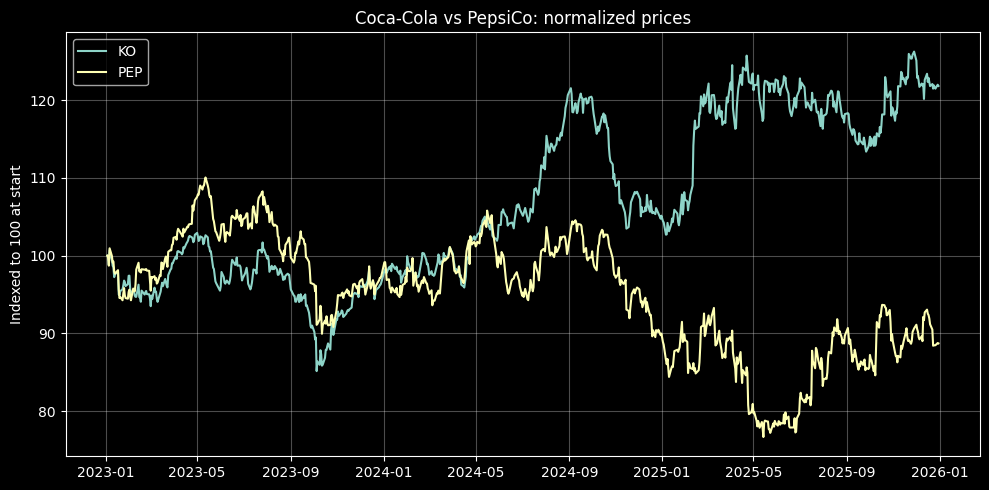

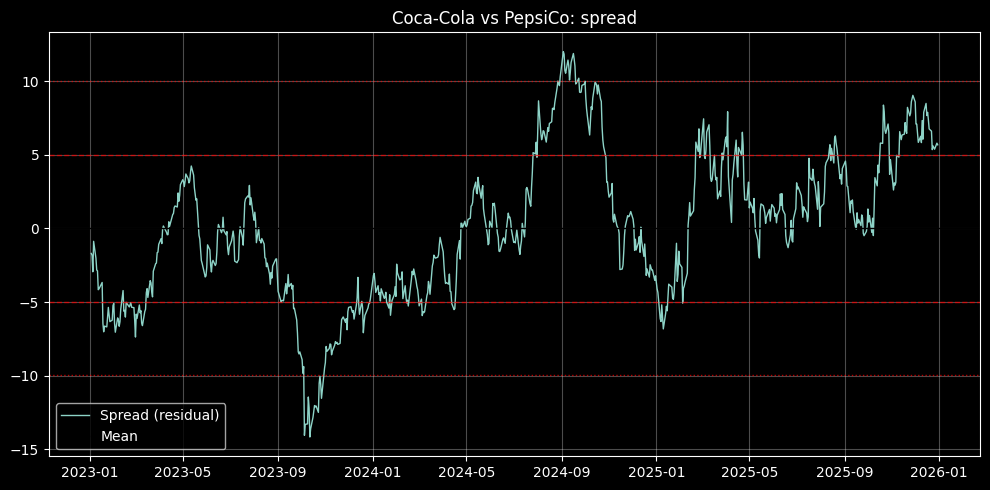

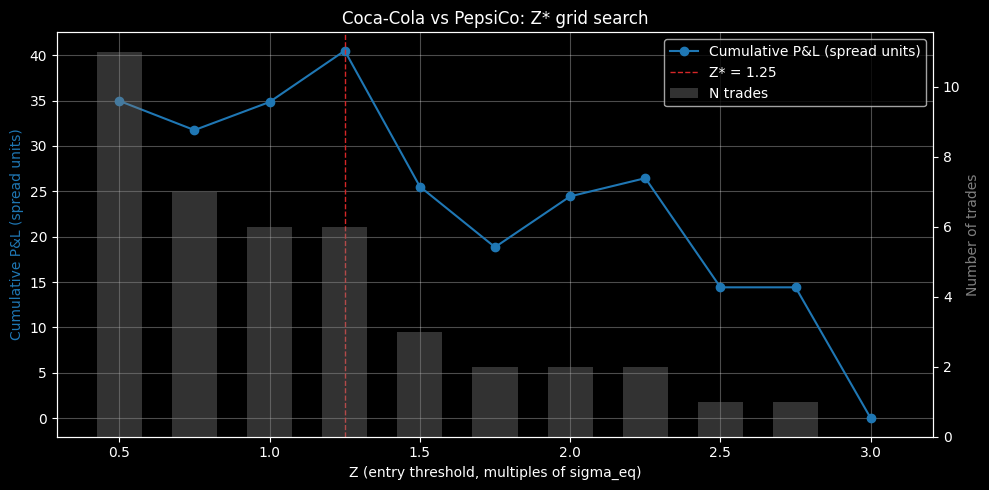

In [3]:
REFRESH_DATA = False  # set True once, to pull fresh prices, then back to False

results = {}
for pair in config.PAIRS:
    results[pair['id']] = run_pair_analysis(pair, refresh_data=REFRESH_DATA)
    print(f"Done: {pair['id']}")


---
# Per-pair analysis

The next section repeats for each pair: price series, stationarity
pre-tests, the Engle-Granger cointegration test with hedge ratio,
residual stationarity, and mean-reversion half-life, and the Z*
threshold grid search.


## Pair 1: Coca-Cola vs PepsiCo (`KO_PEP`)

**Rationale:** *(edit this)* Same-sector consumer staples large caps
with structurally similar demand drivers and pricing power — a
starting point for testing whether sector comovement translates into a
stable cointegrating relationship.


In [4]:
pair_id = 'KO_PEP'
r = results[pair_id]
pair = r['pair']


### Step 1 — Price series

In [5]:
r['price_fig']
plt.show()


### Step 2 — Stationarity pre-tests (ADF + KPSS, levels & first differences)

In [6]:
r['stationarity_summary']


,series,form,adf_stat,adf_pvalue,adf_stationary,kpss_stat,kpss_pvalue,kpss_stationary
0,KO,level,-0.940631,0.774298,False,3.468108,0.01,False
1,KO,diff,-19.733058,0.000000,True,0.073330,0.10,True
2,PEP,level,-1.811068,0.374981,False,2.530587,0.01,False
3,PEP,diff,-20.513640,0.000000,True,0.041592,0.10,True


Expected pattern for I(1) series: non-stationary (`adf_stationary=False`)
in levels, stationary (`adf_stationary=True`) after first-differencing.
Check both tickers fit this pattern before trusting the EG test below.


### Step 3 — Engle-Granger cointegration test

In [7]:
eg = r['eg_result']

print(f"Hedge ratio (beta): {eg['beta']:.4f}")
print(f"Intercept (alpha):  {eg['alpha']:.4f}")
print(f"R-squared:          {eg['r_squared']:.4f}")
print()
print("Manual EG (regress -> ADF on residual):")
print(f"  ADF stat: {eg['manual_adf_stat']:.4f}   p-value: {eg['manual_adf_pvalue']:.4f}")
print(f"  Cointegrated at 5%: {eg['manual_cointegrated']}")
print()
print("statsmodels.coint() cross-check:")
print(f"  EG stat: {eg['builtin_eg_stat']:.4f}   p-value: {eg['builtin_eg_pvalue']:.4f}")
print(f"  Cointegrated at 5%: {eg['builtin_cointegrated_5pct']}")
print()
print(f"Estimated half-life of mean reversion: {eg['half_life_days']:.1f} periods")


Hedge ratio (beta): -0.2780
Intercept (alpha):  102.7628
R-squared:          0.3035

Manual EG (regress -> ADF on residual):
  ADF stat: -2.3046   p-value: 0.1705
  Cointegrated at 5%: False

statsmodels.coint() cross-check:
  EG stat: -2.3066   p-value: 0.3703
  Cointegrated at 5%: False

Estimated half-life of mean reversion: 40.3 periods


In [8]:
r['spread_fig']
plt.show()


**Discussion:** *(fill in per pair)* Does the cointegration result make
economic sense for this pair? Does the half-life look tradeable relative to
your intended holding period? Any visible drift or regime change in the
spread plot worth flagging ahead of the structural-break discussion (Step 5)?


### Step 4 — Z* optimisation

Grid search over the entry/exit threshold Z, showing the trade-off
between number of trades and P&L at each level.


In [9]:
z_opt = r['z_optimisation']
print(f"Selected Z* = {z_opt['z_star']:g} ({z_opt['z_star_source']})")
z_opt['z_stats']


Selected Z* = 1.25 (max_total_pnl)


,z,n_trades,total_pnl,avg_pnl_per_trade,avg_holding_days,open_at_end
0,0.50,11,34.963749,3.178523,46.727273,True
1,0.75,7,31.744592,4.534942,62.000000,True
2,1.00,6,34.841674,5.806946,65.666667,True
3,1.25,6,40.492503,6.748751,61.000000,True
4,1.50,3,25.523936,8.507979,80.333333,True
5,1.75,2,18.846831,9.423415,98.500000,True
6,2.00,2,24.444837,12.222418,96.500000,False
7,2.25,2,26.449435,13.224718,94.500000,False
8,2.50,1,14.421072,14.421072,138.000000,False
9,2.75,1,14.421072,14.421072,138.000000,False


In [10]:
z_opt['fig']
plt.show()


**Discussion:** *(fill in)* What Z* was selected and why? Describe the
trade-off visible in the chart above — does a wider Z reduce N_trades
while increasing average P&L per trade, as expected? Any Z level where
the spread looks likely to have moved into structural-break territory
(ties into Step 5)?


---
> **To add pair 2 and pair 3:** duplicate the whole "Pair 1" block above —
> from its `## Pair 1: ...` heading (with the written rationale) through
> the Step 4 discussion markdown cell (the Step 4 section is part of the
> block) — once per additional pair, updating the heading, the written
> rationale prose, and the `pair_id = '...'` line each time. Keeping each
> pair in its own copy of the block — rather than a loop — makes it easy
> to write pair-specific discussion in markdown between the code cells.


---
# Cross-pair comparison

Side-by-side summary of hedge ratio, cointegration significance,
half-life, and Z* (with its trade count and P&L) across all pairs
studied.


In [11]:
table = comparison_table(results)
table


,pair_id,name,tickers,hedge_ratio_beta,r_squared,eg_pvalue_manual,eg_pvalue_builtin,cointegrated_5pct,half_life_periods,z_star,n_trades_at_z_star,total_pnl_at_z_star
0,KO_PEP,Coca-Cola vs PepsiCo,KO / PEP,-0.277982,0.303465,0.170501,0.370254,False,40.267809,1.25,6,40.492503


In [12]:
table.to_csv(config.OUTPUT_DIR / 'pair_comparison.csv', index=False)
print(f"Saved to {config.OUTPUT_DIR / 'pair_comparison.csv'}")


Saved to /Users/sid/Code/cqf_project/pairs_trading/outputs/pair_comparison.csv


**Comparative discussion:** *(fill in once all pairs are run)* Which
pair showed the strongest/most significant cointegration? Which had the
shortest half-life (fastest mean reversion, more tradeable)? Any pattern
across asset classes (e.g. equities vs ETFs vs FX) worth noting?


---
# Part II — Backtesting (Steps 5–8)

*To be added:* structural break discussion (Step 5), systematic backtest
with equity curve/drawdown/rolling Sharpe (Step 6), train/test split
(Step 7), rolling re-estimation of the cointegrating relationship
(Step 8). These will follow the same pattern as Steps 1–4 — a reusable
function in `src/`, wired into `run_pair_analysis()` in
`src/pipeline.py`, and surfaced in a dedicated section here.
